In [ ]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# plotting style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

DATA_PATH = os.path.join("..", "data", "raw", "kaggle_dataset_complete.csv")

# load raw dataset
df = pd.read_csv(DATA_PATH)
print("Dataset loaded successfully!")
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")

Dataset loaded successfully!
Shape: 7308 rows, 9 columns


In [ ]:
# preview first 5 rows
print("--- First 5 Rows ---")
display(df.head())

# preview last 5 rows
print("--- Last 5 Rows ---")
display(df.tail())

--- First 5 Rows ---


,Date,Location,Rainfall_mm,WaterLevel_m,SoilMoisture_pct,Elevation_m,FloodOccurrence,FloodDepth_m,RiskLevel
0,2016-01-01,Quezon City,12.0,0.5,15.3,43,0,0.0,Low
1,2016-01-01,Marikina,10.6,1.8,23.2,15,0,0.0,Low
2,2016-01-01,Manila,5.7,0.5,15.6,5,0,0.0,Low
3,2016-01-01,Pasig,3.7,0.5,5.0,5,0,0.0,Low
4,2016-01-02,Quezon City,3.4,0.5,13.3,43,0,0.0,Low


--- Last 5 Rows ---


,Date,Location,Rainfall_mm,WaterLevel_m,SoilMoisture_pct,Elevation_m,FloodOccurrence,FloodDepth_m,RiskLevel
7303,2020-12-30,Pasig,16.9,1.4,16.8,5,0,0.0,Low
7304,2020-12-31,Quezon City,7.2,0.7,25.6,43,0,0.0,Low
7305,2020-12-31,Marikina,4.8,1.3,9.6,15,0,0.0,Low
7306,2020-12-31,Manila,7.4,1.0,11.9,5,0,0.0,Low
7307,2020-12-31,Pasig,7.8,1.5,7.3,5,0,0.0,Low


In [3]:
# check column data types, total entries, and non-null counts
print("--- DataFrame Info ---")
df.info()

--- DataFrame Info ---
<class 'pandas.DataFrame'>
RangeIndex: 7308 entries, 0 to 7307
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date              7308 non-null   str    
 1   Location          7308 non-null   str    
 2   Rainfall_mm       7308 non-null   float64
 3   WaterLevel_m      7308 non-null   float64
 4   SoilMoisture_pct  7308 non-null   float64
 5   Elevation_m       7308 non-null   int64  
 6   FloodOccurrence   7308 non-null   int64  
 7   FloodDepth_m      7308 non-null   float64
 8   RiskLevel         7308 non-null   str    
dtypes: float64(4), int64(2), str(3)
memory usage: 514.0 KB


In [4]:
# total null values per column
print("--- Missing Values Per Column ---")
missing_counts = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing_counts, 'Percentage (%)': missing_percent})
display(missing_df)

# duplicate rows across all columns
duplicate_count = df.duplicated().sum()
print(f"Total duplicate rows: {duplicate_count}")

--- Missing Values Per Column ---


,Missing Count,Percentage (%)
Date,0,0.0
Location,0,0.0
Rainfall_mm,0,0.0
WaterLevel_m,0,0.0
SoilMoisture_pct,0,0.0
Elevation_m,0,0.0
FloodOccurrence,0,0.0
FloodDepth_m,0,0.0
RiskLevel,0,0.0


Total duplicate rows: 0


In [ ]:
numeric_columns = ["Rainfall_mm", "WaterLevel_m", "SoilMoisture_pct", "FloodDepth_m"]

print("--- Numerical Summary Statistics ---")
display(df[numeric_columns].describe().T.round(4))

--- Numerical Summary Statistics ---


,count,mean,std,min,25%,50%,75%,max
Rainfall_mm,7308.0,10.0529,7.1018,0.1,4.9,8.4,13.5,52.70
WaterLevel_m,7308.0,1.2664,0.9022,0.5,0.5,1.0,1.8,6.40
SoilMoisture_pct,7308.0,15.1850,5.9940,5.0,10.9,14.9,19.1,39.70
FloodDepth_m,7308.0,0.0155,0.1230,0.0,0.0,0.0,0.0,1.63



--- RiskLevel Class Distribution ---


,Count,Percentage (%)
RiskLevel,,
Low,7198,98.49
Moderate,63,0.86
High,47,0.64


--- Records per City ---


Location
Quezon City    1827
Marikina       1827
Manila         1827
Pasig          1827
Name: count, dtype: int64


--- FloodOccurrence Distribution ---


,Count,Percentage (%)
FloodOccurrence,,
0,7176,98.19
1,132,1.81



--- RiskLevel Class Distribution ---


,Count,Percentage (%)
RiskLevel,,
Low,7198,98.49
Moderate,63,0.86
High,47,0.64


C:\Users\My PC\AppData\Local\Temp\ipykernel_23788\1436601400.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\My PC\AppData\Local\Temp\ipykernel_23788\1436601400.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="FloodOccurrence", ax=axes[1], palette="coolwarm")
C:\Users\My PC\AppData\Local\Temp\ipykernel_23788\1436601400.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="RiskLevel", ax=axes[2],


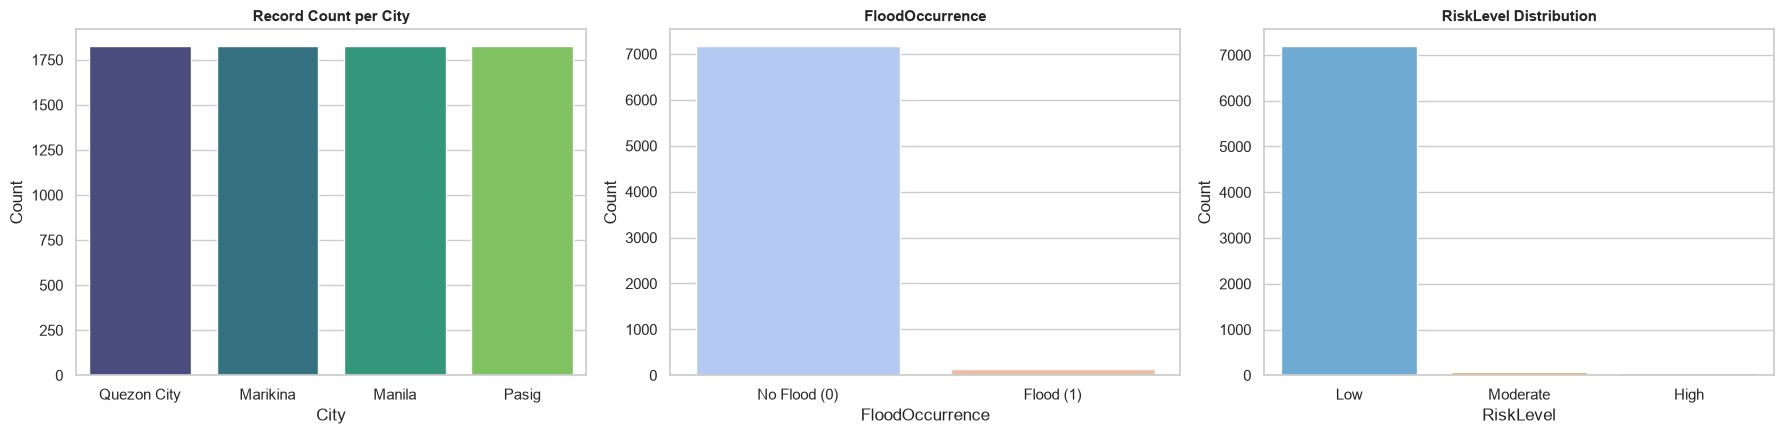

In [6]:
# city count verification and class imbalance
print("--- Records per City ---")
display(df["Location"].value_counts())

print("\n--- FloodOccurrence Distribution ---")
flood_counts = df["FloodOccurrence"].value_counts()
flood_percent = df["FloodOccurrence"].value_counts(normalize=True) * 100
display(pd.DataFrame({"Count": flood_counts, "Percentage (%)": flood_percent.round(2)}))

if "RiskLevel" in df.columns:
    print("\n--- RiskLevel Class Distribution ---")
    risk_counts = df["RiskLevel"].value_counts(dropna=False)
    risk_pcts = df["RiskLevel"].value_counts(dropna=False, normalize=True).mul(100).round(2)
    display(pd.DataFrame({"Count": risk_counts, "Percentage (%)": risk_pcts}))

has_risk = "RiskLevel" in df.columns
ncols = 3 if has_risk else 2
fig, axes = plt.subplots(nrows=1, ncols=ncols, figsize=(6 * ncols, 4.5))

# location distribution
sns.countplot(
    data=df,
    x="Location",
    ax=axes[0],
    palette="viridis",
    order=df["Location"].value_counts().index,
)
axes[0].set_title("Record Count per City", fontsize=11, fontweight="bold")
axes[0].set_ylabel("Count")
axes[0].set_xlabel("City")

# FloodOccurrence distribution
sns.countplot(data=df, x="FloodOccurrence", ax=axes[1], palette="coolwarm")
axes[1].set_title("FloodOccurrence", fontsize=11, fontweight="bold")
axes[1].set_ylabel("Count")
axes[1].set_xlabel("FloodOccurrence")
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["No Flood (0)", "Flood (1)"])

# RiskLevel distribution
if has_risk:
    risk_order = ["Low", "Moderate", "High"] if set(df["RiskLevel"].dropna().unique()).issubset({"Low", "Moderate", "High"}) else None
    sns.countplot(data=df, x="RiskLevel", ax=axes[2], 
    palette={
        "Low": "#5dade2",
        "Moderate": "#f5b041",
        "High": "#e74c3c"
    }, order=risk_order)
    axes[2].set_title("RiskLevel Distribution", fontsize=11, fontweight="bold")
    axes[2].set_ylabel("Count")
    axes[2].set_xlabel("RiskLevel")

plt.tight_layout()
plt.show()

In [7]:
# group by City to check Elevation statistics (mean, std, min, max)
elevation_check = df.groupby("Location")["Elevation_m"].agg(
    ["count", "min", "max", "mean", "std"]
)
print("--- Elevation Variance by City (checking std = 0) ---")
display(elevation_check)

# explicit boolean check
is_static = (elevation_check["std"] == 0).all()
print(
    f"Formally confirmed: Elevation is a static city-level constant -> {is_static}"
)

--- Elevation Variance by City (checking std = 0) ---


,count,min,max,mean,std
Location,,,,,
Manila,1827,5,5,5.0,0.0
Marikina,1827,15,15,15.0,0.0
Pasig,1827,5,5,5.0,0.0
Quezon City,1827,43,43,43.0,0.0


Formally confirmed: Elevation is a static city-level constant -> True


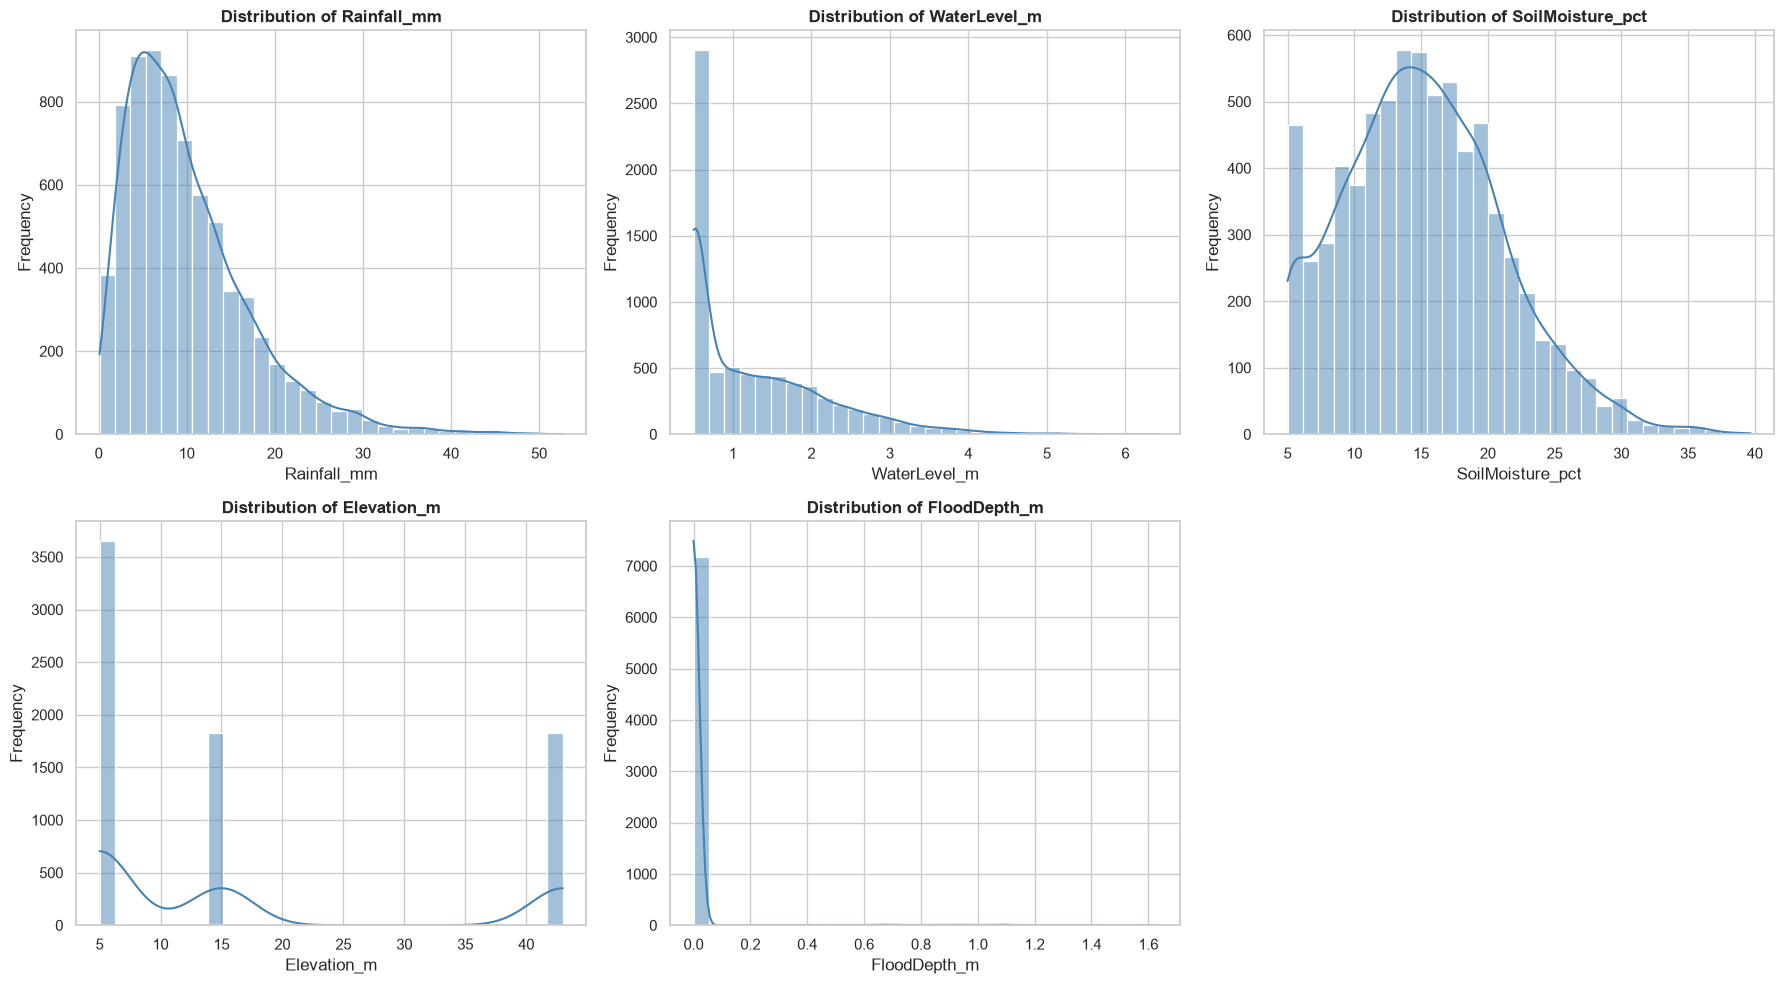

In [8]:
numeric_cols = [
    "Rainfall_mm",
    "WaterLevel_m",
    "SoilMoisture_pct",
    "Elevation_m",
    "FloodDepth_m"
]

# subplot grid
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[idx], color="steelblue", bins=30)
    axes[idx].set_title(f"Distribution of {col}", fontsize=12, fontweight="bold")
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel("Frequency")

axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

--- IQR Statistical Outlier Detection Summary ---


,Variable,Q1 (25th),Q2 (50th),Q3 (75th),IQR,Lower Bound,Upper Bound,IQR Outlier Count,IQR Outlier Percent,Physical Sensor Errors
0,Rainfall_mm,4.9,8.4,13.5,8.6,-8.00,26.40,249,3.41%,0
1,WaterLevel_m,0.5,1.0,1.8,1.3,-1.45,3.75,129,1.77%,0
2,SoilMoisture_pct,10.9,14.9,19.1,8.2,-1.40,31.40,62,0.85%,0
3,FloodDepth_m,0.0,0.0,0.0,0.0,0.00,0.00,132,1.81%,0


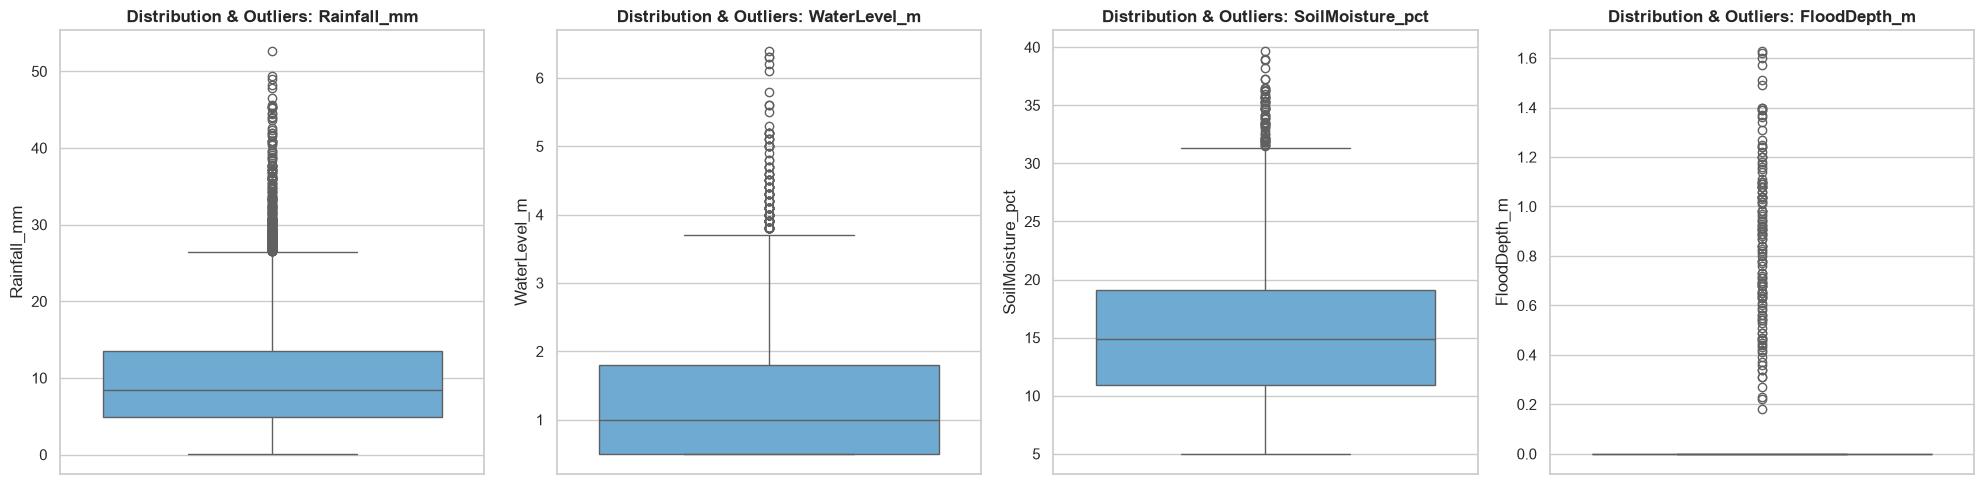

In [9]:
# outlier detection (IQR method)

continuous_cols = ["Rainfall_mm", "WaterLevel_m", "SoilMoisture_pct", "FloodDepth_m"]
outlier_summary = []

for col in continuous_cols:
    q1 = df[col].quantile(0.25)
    q2 = df[col].quantile(0.5)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    # outliers (not removed unless physical errors)
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    # physically impossible sensor errors
    if col == "SoilMoisture_pct":
        physical_errors = df[(df[col] < 0) | (df[col] > 100)]
    else:
        physical_errors = df[df[col] < 0] # negative

    outlier_summary.append(
        {
            "Variable": col,
            "Q1 (25th)": round(q1, 2),
            "Q2 (50th)": round(q2, 2),
            "Q3 (75th)": round(q3, 2),
            "IQR": round(iqr, 2),
            "Lower Bound": round(lower_bound, 2),
            "Upper Bound": round(upper_bound, 2),
            "IQR Outlier Count": len(outliers),
            "IQR Outlier Percent": f"{(len(outliers) / len(df)) * 100:.2f}%",
            "Physical Sensor Errors": len(physical_errors),
        }
    )

iqr_df = pd.DataFrame(outlier_summary)
print("--- IQR Statistical Outlier Detection Summary ---")
display(iqr_df)

# boxplots
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for i, col in enumerate(continuous_cols):
    sns.boxplot(y=df[col], ax=axes[i], color="#5dade2")
    axes[i].set_title(f"Distribution & Outliers: {col}", fontweight="bold")
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

In [10]:
# Justification of not removing the outliers
rf_upper = iqr_df.loc[iqr_df['Variable'] == 'Rainfall_mm', 'Upper Bound'].values[0]
wl_upper = iqr_df.loc[iqr_df['Variable'] == 'WaterLevel_m', 'Upper Bound'].values[0]
fd_upper = iqr_df.loc[iqr_df['Variable'] == 'FloodDepth_m', 'Upper Bound'].values[0]

severe_events_sample = df[
    (df['Rainfall_mm'] > rf_upper) | 
    (df['WaterLevel_m'] > wl_upper) |
    (df['FloodDepth_m'] > fd_upper)
].copy()

print(f"Identified outliers are not removed unless it provides physical sensor errors. \nThis avoids training the system without extreme weather conditions displayed in real-life high-risk disasters.")
print(f"\nTotal severe event records identified: {len(severe_events_sample)}")
print("--- Sample of Top 5 Extreme Hydrometeorological Events Retained ---")

display(
    severe_events_sample[['Date', 'Location', 'Rainfall_mm', 'WaterLevel_m', 'SoilMoisture_pct', 'FloodDepth_m', 'FloodOccurrence']]
    .sort_values(by=['FloodDepth_m', 'Rainfall_mm'], ascending=False)
    .head(5)
)

Identified outliers are not removed unless it provides physical sensor errors. 
This avoids training the system without extreme weather conditions displayed in real-life high-risk disasters.

Total severe event records identified: 305
--- Sample of Top 5 Extreme Hydrometeorological Events Retained ---


,Date,Location,Rainfall_mm,WaterLevel_m,SoilMoisture_pct,FloodDepth_m,FloodOccurrence
2065,2017-05-31,Marikina,43.9,6.1,27.4,1.63,1
6065,2020-02-25,Marikina,46.5,6.4,34.8,1.62,1
6113,2020-03-08,Marikina,49.4,6.3,29.7,1.60,1
124,2016-02-01,Quezon City,48.2,6.3,39.7,1.57,1
4234,2018-11-24,Manila,41.7,5.6,20.7,1.51,1


--- Distribution Shape & Statistical Normality Metrics ---


,Variable,Skewness,Excess Kurtosis,D'Agostino K² Stat,p-value,Zero Count,Zero Pct,Shape Profile
0,Rainfall_mm,1.4306,2.8594,1930.19,0.0000e+00,0,0.00%,Right-Skewed / Leptokurtic
1,WaterLevel_m,1.3476,1.8386,1634.87,0.0000e+00,0,0.00%,Right-Skewed / Leptokurtic
2,SoilMoisture_pct,0.4459,0.0978,224.60,1.6955e-49,0,0.00%,Approximately Symmetric
3,FloodDepth_m,8.6345,78.5983,10333.12,0.0000e+00,7176,98.19%,Right-Skewed / Leptokurtic


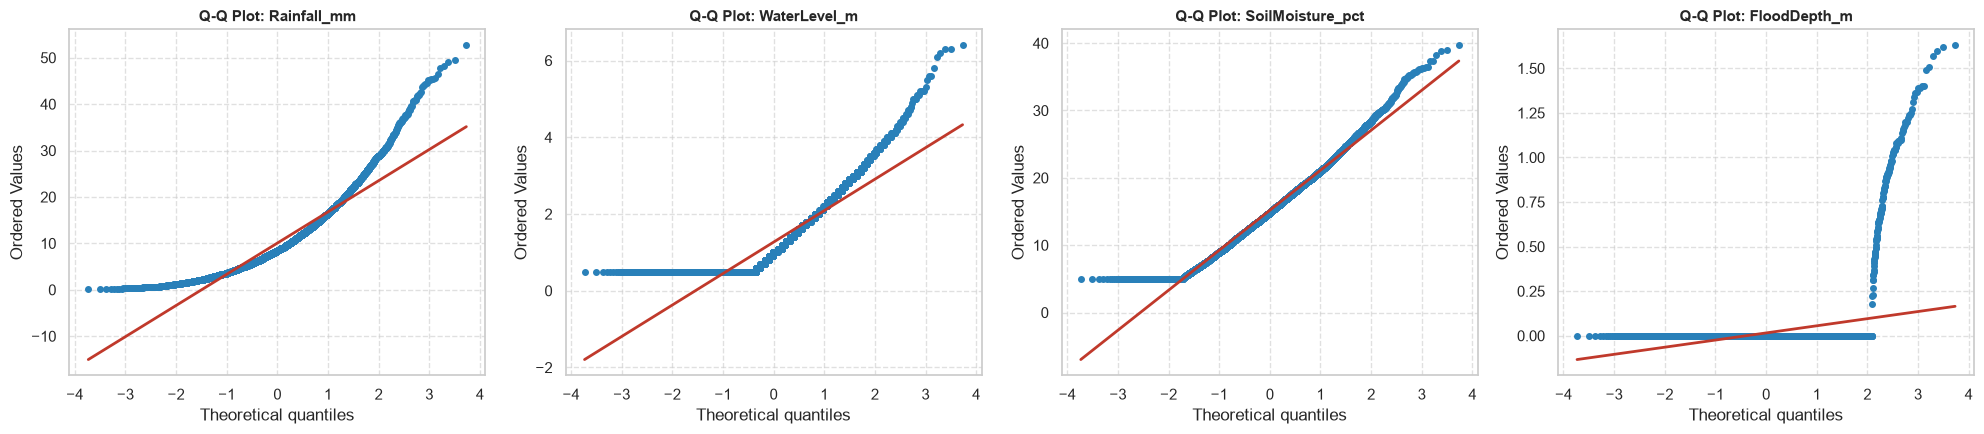

In [11]:
# Normality Assessment (uses non-normal distribution to help justify CART)
import scipy.stats as stats

# numerical normality metrics (Skewness, Kurtosis, D'Agostino K^2)
normality_records = []

for col in continuous_cols:
    data = df[col].dropna()
    skew_val = stats.skew(data)
    kurt_val = stats.kurtosis(data)  # Fisher excess kurtosis (normal = 0.0)

    # D'Agostino's K^2 omnibus normality test
    k2_stat, k2_p = stats.normaltest(data)

    normality_records.append(
        {
            "Variable": col,
            "Skewness": round(skew_val, 4),
            "Excess Kurtosis": round(kurt_val, 4),
            "D'Agostino K² Stat": round(k2_stat, 2),    # reject h0 if > 5.99
            "p-value": f"{k2_p:.4e}",   # reject h0 if p < 0.05
            "Zero Count": (data == 0).sum(),
            "Zero Pct": f"{((data == 0).sum() / len(data)) * 100:.2f}%",
            "Shape Profile": (
                "Right-Skewed / Leptokurtic"
                if skew_val > 0.5 and kurt_val > 0
                else "Right-Skewed"
                if skew_val > 0.5
                else "Left-Skewed"
                if skew_val < -0.5
                else "Approximately Symmetric"
            ),
        }
    )

normality_df = pd.DataFrame(normality_records)
print("--- Distribution Shape & Statistical Normality Metrics ---")
display(normality_df)

# visual Q-Q plots (Quantile-Quantile vs. Theoretical Normal Distribution)
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))

for i, col in enumerate(continuous_cols):
    stats.probplot(df[col], dist="norm", plot=axes[i])
    axes[i].get_lines()[0].set_markerfacecolor("#2980b9")
    axes[i].get_lines()[0].set_markeredgecolor("#2980b9")
    axes[i].get_lines()[0].set_markersize(4)
    axes[i].get_lines()[1].set_color("#c0392b")  # Reference normal line
    axes[i].get_lines()[1].set_linewidth(2)
    axes[i].set_title(f"Q-Q Plot: {col}", fontweight="bold", fontsize=11)
    axes[i].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

In [12]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# prepare feature matrix with continuous variables and one-hot encoded city columns
vif_df_input = df[
    ["Rainfall_mm", "WaterLevel_m", "SoilMoisture_pct", "Elevation_m"]
].copy()
city_dummies = pd.get_dummies(
    df["Location"], prefix="Loc", drop_first=True, dtype=float
)
vif_features = pd.concat([vif_df_input, city_dummies], axis=1)

# add intercept constant (required for standard VIF computation)
vif_features.insert(0, "const", 1.0)

# calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["Feature"] = vif_features.columns
vif_data["VIF"] = [
    variance_inflation_factor(vif_features.values, i)
    for i in range(vif_features.shape[1])
]

print("--- Variance Inflation Factor (VIF) Table ---")
display(vif_data.sort_values(by="VIF", ascending=False))

--- Variance Inflation Factor (VIF) Table ---


C:\Users\My PC\AppData\Local\Temp\ipykernel_23788\266245751.py:19: UserWarning: The design matrix is poorly conditioned (condition number=2.05e+15). VIF calculations may be numerically unstable.
  variance_inflation_factor(vif_features.values, i)
c:\Users\My PC\OneDrive\Desktop\flood-risk-system\venv\Lib\site-packages\statsmodels\stats\outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
c:\Users\My PC\OneDrive\Desktop\flood-risk-system\venv\Lib\site-packages\statsmodels\stats\outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
c:\Users\My PC\OneDrive\Desktop\flood-risk-system\venv\Lib\site-packages\statsmodels\stats\outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely

,Feature,VIF
5,Loc_Marikina,1.000800e+15
7,Loc_Quezon City,1.000800e+15
4,Elevation_m,1.000800e+15
1,Rainfall_mm,2.057592e+00
2,WaterLevel_m,1.556262e+00
3,SoilMoisture_pct,1.506860e+00
6,Loc_Pasig,1.500444e+00
0,const,1.000000e+00


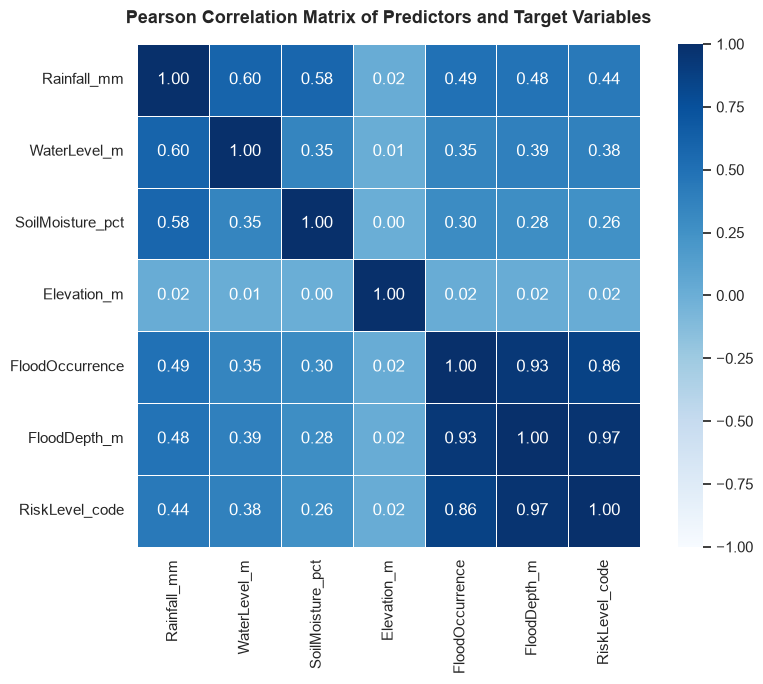

--- Predictor Correlations with FloodDepth_m (Continuous Target) ---


FloodDepth_m        1.000000
RiskLevel_code      0.967419
FloodOccurrence     0.931468
Rainfall_mm         0.476654
WaterLevel_m        0.387000
SoilMoisture_pct    0.277784
Elevation_m         0.017641
Name: FloodDepth_m, dtype: float64


--- Predictor Correlations with RiskLevel_code (Classification Target) ---


RiskLevel_code      1.000000
FloodDepth_m        0.967419
FloodOccurrence     0.860509
Rainfall_mm         0.443153
WaterLevel_m        0.378101
SoilMoisture_pct    0.256108
Elevation_m         0.018158
Name: RiskLevel_code, dtype: float64

In [13]:
# pearson correlation matrix
corr_cols = [
    "Rainfall_mm",
    "WaterLevel_m",
    "SoilMoisture_pct",
    "Elevation_m",
    "FloodOccurrence",
    "FloodDepth_m",
]

corr_df = df[corr_cols].copy()

if "RiskLevel" in df.columns:
    risk_mapping = {"Low": 0, "Moderate": 1, "High": 2}

    corr_df["RiskLevel_code"] = (
        df["RiskLevel"].astype(str).str.strip().map(risk_mapping)
    )
    
corr_matrix = corr_df.corr(numeric_only=True)

plt.figure(figsize=(9, 7))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    vmin=-1,
    vmax=1,
    cbar=True,
    square=True,
    linewidths=0.5,
)
plt.title(
    "Pearson Correlation Matrix of Predictors and Target Variables",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.tight_layout()
plt.show()

print("--- Predictor Correlations with FloodDepth_m (Continuous Target) ---")
display(corr_matrix["FloodDepth_m"].sort_values(ascending=False))

if "RiskLevel_code" in corr_matrix.columns:
    print(
        "\n--- Predictor Correlations with RiskLevel_code (Classification Target) ---"
    )
    display(corr_matrix["RiskLevel_code"].sort_values(ascending=False))

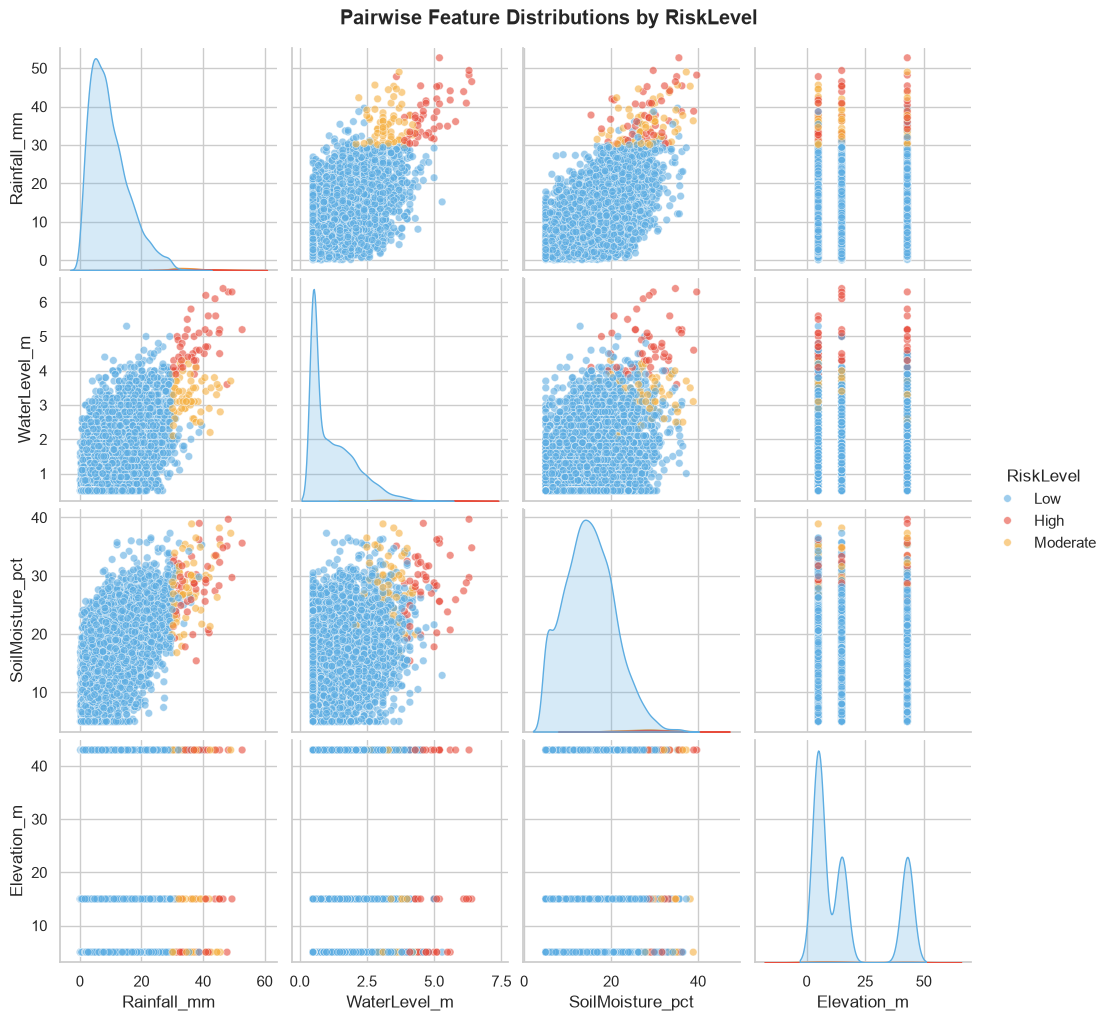

In [14]:
# pairwise relationship inspection
hue_col = "RiskLevel" if "RiskLevel" in df.columns else "FloodOccurrence"

pairplot_fig = sns.pairplot(
    df,
    vars=["Rainfall_mm", "WaterLevel_m", "SoilMoisture_pct", "Elevation_m"],
    hue=hue_col,
    palette={
        "Low": "#5dade2",
        "Moderate": "#f5b041",
        "High": "#e74c3c"
    },
    diag_kind="kde",
    plot_kws={"alpha": 0.6, "s": 30},
)
pairplot_fig.fig.suptitle(
    f"Pairwise Feature Distributions by {hue_col}", y=1.02, fontweight="bold"
)
plt.show()

## Exploratory Data Analysis Summary & Key Observations

### 1. Dataset Structure & Quality
- Evaluated raw daily historical data across four study cities: Manila, Marikina, Quezon City, and Pasig (2016–2020) using data/raw/kaggle_dataset_complete.csv.
- Verified data types, total record counts, missing/null values, and duplicate records. Each city contains 1,827 daily records (7,308 total), with zero missing values or duplicate records identified.
- Described data numerical statistics (`Rainfall_mm`, `WaterLevel_m`, `SoilMoisture_pct`, `Elevation_m`, `FloodDepth_m`) with mean, std, min and maximum value, and q1-q3 percentile.
   - FloodDepth_m showed expected 0.0 values for quartile 1 to 3, given imbalanced FloodOccurence values.
   - Presented `RiskLevel` Class Distribution with Low count of 7198 (98.49%), Moderate count of 63 (0.86%), and High count of 47 (0.64%). 
- Displayed number of records per city (1827) and FloodOccurence distribution table for class balance: 0 with 7176 count, 98.19%; 1 with 132 count, 1.81%.
- Confirmed `Elevation_m` as static city-level constant for each city by grouping values per city and checking statistics (zero variance, std = 0.0).

### 2. Identified Features & Targets and Distributions of Numeric Columns
- **Predictors (X):** Rainfall_mm, WaterLevel_m, SoilMoisture_pct, Elevation_m, and Location (categorical). 
- **Targets (Y):** FloodDepth_m (regression), RiskLevel (classification)
- **Distribution of each numeric columns:** Rainfall and River Water Level are right-skewed (concentrated at lower values with extreme peak events). Soil Moisture exhibits a centralized distribution. Elevation clusters into 3 unique tiers (5 m, 15 m, 43 m) across the 4 locations. Flood Depth is severely zero-inflated with a positive tail up to 1.6 m, violating linear model assumptions and justifying non-parametric CART.

### 3. Outlier Treatment &  Justification
- **Statistical Detection (1.5 × IQR Thresholds):**
   - Statistical outliers were detected via the IQR rule: `Rainfall_mm` (249 rows, 3.41%), `WaterLevel_m` (129 rows, 1.77%), and `SoilMoisture_pct` (62 rows, 0.85%). `FloodDepth_m` showed 132 rows (1.81%) which is also the number of positive flood occurence.
   - These thresholds reflect the episodic nature of tropical storm systems in the Philippines rather than measurement anomalies.

- **Sensor Validity vs. Severe Weather Events:**
   - **Physical Sensor Errors:** Defined as impossible values (< 0 for any hydrologic metric, or > 100% for soil saturation). **Result: Exactly 0 physical errors detected.**
   - **Legitimate Severe Events:** The flagged rows represent verified heavy monsoon and tropical storm days where river levels rose and flood risks materialized.

- **Methodological Decision — Retention Policy:**
   - **Strict Non-Removal:** All flagged statistical outliers are **intentionally retained**.
   - In disaster risk reduction (DRR) modeling, extreme meteorological peaks contain the vital signal required to classify high-risk flood events. Deleting or capping these observations would strip the training distribution of genuine hazard patterns, introducing dangerous false negatives during real-world typhoons.

### 4. Distribution Shape & Statistical Normality Metrics (Q-Q plots, Skewness, Kurtosis, D'Agostino's K²)

- **Empirical Findings:**
   - **Right-Skewed Distributions:** Continuous environmental predictors (`Rainfall_mm` and `WaterLevel_m`) show noticeable right-skewness and heavy upper tails (extreme storm peaks). `SoilMoisture_pct` is mostly balanced and centered.
   - **Severe Zero-Inflation (`FloodDepth_m`):** The target variable has an extreme right-skew (8.63) because **98.19% of the records (7,176 rows) are exactly 0 m** (no flood occurred).
   - **Q-Q Plot Curvature:**
      - The blue dots for `Rainfall_mm` and `WaterLevel_m` pull away from the red diagonal line at the high end, showing heavy right tails.
      - `FloodDepth_m` stays completely flat at 0 for almost the whole line, then shoots straight up at the very end.

   - **Statistical Tests:** D'Agostino's K^2 gives p < 0.001 for all variables, confirming they are not normally distributed. (Note: With over 7,000 rows of data, these statistical tests are secondary to visual plots, since large datasets flag even tiny deviations).

- **Methodological Implication (Linear vs. CART Models):**
   - **Parametric Vulnerability (Linear Regression):** Standard Linear Regression assumes errors follow a normal bell curve. Because `FloodDepth_m` is 98% zeros, a straight-line model struggles—it often predicts nonsensical negative flood depths on dry days and gets pulled off-track by rare, extreme spikes.
   - **Tree-Based Invariance (CART):** Decision trees are **non-parametric**. They do not expect data to follow a bell curve. Instead, CART simply uses `if-else` threshold cutoffs (e.g., `IF Rainfall > 30 mm`), easily keeping the 98% zero-depth days in flat zero buckets while handling rare high depths on separate branches.
   - **Conclusion:** The non-normal predictor data combined with the heavy zero-inflation of `FloodDepth_m` provides clear statistical justification for choosing CART over linear models.

### 5. Collinearity Diagnostics (VIF)
- Including one-hot encoded City dummies alongside continuous features yields near-infinite/extreme VIF for Elevation, confirming perfect linear dependency between Elevation and City categories.
- **Constraint:** Multiple Linear Regression and Logistic Regression baselines must exclude Elevation_m (and drop one reference dummy) to avoid matrix singularity. CART models retain all features due to their inherent robustness to collinear inputs.

### 6. Correlation Analysis
- **Pearson Correlation Matrix:** Performed bivariate correlation analysis across all predictors (Rainfall_mm, WaterLevel_m, SoilMoisture_pct, Elevation_m) against the final targets (FloodDepth_m and RiskLevel_code).
   - **Predictor vs Target:** `Rainfall_mm` exhibits the strongest linear association (r = 0.48 with depth, r = 0.44 with risk level), followed by `WaterLevel_m` (r = 0.39 with depth, r = 0.38 with risk level) and `SoilMoisture_pct` (r = 0.28 with depth, r = 0.26 with risk level).
   - **Inter-feature dynamics:** Moderate inter-feature correlations between rainfall and water level (r = 0.60) as well as soil moisture (r = 0.58), remaining below critical multicollinearity thresholds (r of 0.80 or higher).
   - **Non-Linear Nature of Elevation:** `Elevation_m`  shows near-zero linear correlation (r <= 0.02) with all variables, confirming that elevation acts via localized threshold cutoffs rather than continuous linear gradients.
   - **Target Alignment:** Continuous depth and ordinal risk level correlate nearly perfectly (r = 0.97), validating that the risk categories accurately map physical water depth.

- **Pairwise Feature Distributions by RiskLevel:** Inspection of Rainfall_mm, WaterLevel_m, SoilMoisture_pct, and Elevation_m grouped by the classification target RiskLevel (Low, Moderate, High) reveals clear non-linear dynamics:
   - Threshold-Based Separation: Risk classes separate along sharp cutoff thresholds rather than continuous diagonal slopes:
      - Low Risk (Blue): Dominates routine baseline observations (Rainfall_mm < 30 mm, WaterLevel_m < 3.5 m).
      - Moderate Risk (Yellow): Forms an intermediate transition zone, emerging primarily when rainfall exceeds approximately 30 mm and river stages rise above approximately 3.5 m.
      - High Risk (Red): Concentrates at compound extremes, requiring both elevated precipitation (Rainfall_mm > 35 mm) and high river stage (WaterLevel_m > 4.5 m) alongside high soil saturation (SoilMoisture_pct > 25%).
   - Elevation_m forms static bands (5 m, 15 m, 43 m). Moderate and High risk points appear across all elevation tiers once rainfall and river levels spike, matching its near-zero linear correlation ($r = 0.02$).
   - Clusters exhibit rectangular, axis-parallel separation boundaries rather than smooth linear gradients, directly aligning with CART's orthogonal if-else recursive splitting logic.

### 7. Target Independence
- `FloodDepth_m` (regression) and `RiskLevel` (classification) are modeled independently in separate training pipelines.
- Neither target is used as an input feature to predict the other.
- Historical `FloodOccurrence` is strictly reserved for baseline comparison and auditing, and is completely excluded from feature matrix X.